<a href="https://colab.research.google.com/github/WenqiaoDuan/econ5200-lab03-eda-diagnostics/blob/main/lab_ch03_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Pipeline Health Check — Finding Data Corruption Through EDA

**ECON 5200: Causal Machine Learning & Applied Analytics**

This lab uses a **diagnosis-first** format. You will:
1. Find and fix 5 planted data quality issues in a deliberately corrupted dataset using EDA alone
2. Build automated distribution diagnostics that detect shifts between training and inference data
3. Compare manual EDA to automated profiling (ydata-profiling) and identify what each misses
4. Write a reusable `eda_utils.py` module with distribution checking and anomaly detection functions

**Time estimate:** 45-60 minutes

**Prerequisites:** Chapter 3 reading, including [5200-DEPTH] sections on distribution diagnostics and data pipeline monitoring

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("Setup complete!")

Setup complete!


<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 15 min)

Part 1 hands you a merged dataset with five things wrong with it and asks you
to find them all using EDA alone. Before you can spot corruption, you need to
know what a healthy profile of a clean panel looks like, and you need the
pandas verbs that produce one.

**This lab's slice of the floor:** `.groupby()`, `.map()` / `.apply()`, the
three loop helpers you will read constantly (`zip`, `enumerate`, `range`), and
`try` / `except`.

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0a: groupby, map, apply
# -----------------------------------------------------------
import pandas as pd
import numpy as np

clean = pd.DataFrame({
    "country":   ["USA", "USA", "China", "China", "Brazil", "Brazil"],
    "year":      [2022, 2023, 2022, 2023, 2022, 2023],
    "gdp":       [25.7, 27.4, 17.9, 18.5, 1.92, 2.17],     # trillions USD
    "region":    ["Americas", "Americas", "Asia", "Asia", "Americas", "Americas"],
})

# .groupby(col) SPLITS the table into one group per distinct value, APPLIES an
# aggregation to each, and COMBINES the answers. Split -> apply -> combine.
print("Mean GDP by region:")
print(clean.groupby("region")["gdp"].mean().round(2))

# Note what came back: a Series whose INDEX is the region. groupby always turns
# the grouping column into the index. .reset_index() pushes it back to a column.
print("\nSeveral statistics at once — .agg():")
print(clean.groupby("country")["gdp"].agg(["count", "mean", "max"]).round(2))

# .map() applies a function to EVERY VALUE of a Series and returns a new one.
# `lambda x: ...` is a one-expression function with no name, handed to .map()
# so it can be run once per value.
clean["gdp_billions"] = clean["gdp"].map(lambda x: x * 1000)

# .map() also takes a DICT, which is how you recode labels.
clean["region_code"] = clean["region"].map({"Americas": "AM", "Asia": "AS"})

# .apply(axis=1) hands your function an entire ROW rather than one value.
clean["label"] = clean.apply(
    lambda row: f"{row['country']} {row['year']}: ${row['gdp']:.2f}T", axis=1
)
print("\n" + "\n".join(clean["label"]))

Mean GDP by region:
region
Americas    14.3
Asia        18.2
Name: gdp, dtype: float64

Several statistics at once — .agg():
         count   mean    max
country                     
Brazil       2   2.04   2.17
China        2  18.20  18.50
USA          2  26.55  27.40

USA 2022: $25.70T
USA 2023: $27.40T
China 2022: $17.90T
China 2023: $18.50T
Brazil 2022: $1.92T
Brazil 2023: $2.17T


In [ ]:
clean.head()

,country,year,gdp,region,gdp_billions,region_code,label
0,USA,2022,25.70,Americas,25700.0,AM,USA 2022: $25.70T
1,USA,2023,27.40,Americas,27400.0,AM,USA 2023: $27.40T
2,China,2022,17.90,Asia,17900.0,AS,China 2022: $17.90T
3,China,2023,18.50,Asia,18500.0,AS,China 2023: $18.50T
4,Brazil,2022,1.92,Americas,1920.0,AM,Brazil 2022: $1.92T


In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0b: the loop helpers, and try / except
# -----------------------------------------------------------

countries = ["USA", "China", "Brazil"]
gdp       = [27.4, 18.5, 2.17]

# zip() walks two lists side by side, one pair per step.
for name, value in zip(countries, gdp):
    print(f"  {name:<8}${value:>6.2f}T")

# enumerate() walks a list while counting positions — `i` is 0, 1, 2 ...
# This is the form you will read in every multi-panel plotting cell.
print()
for i, name in enumerate(countries):
    print(f"  panel {i}: {name}")

# range(n) repeats n times. The throwaway `_` means "I do not need this value".
total = 0
for _ in range(3):
    total += 1
print(f"\nRepeated 3 times, total = {total}")

# try / except catches ONE SPECIFIC failure and carries on. Always name the
# exception you expect; a bare `except:` swallows real bugs and leaves you
# debugging blind.
raw = ["3.1", "2.5", "n/a", "4.5", ""]
cleaned = []
for item in raw:
    try:
        cleaned.append(float(item))
    except ValueError:
        cleaned.append(np.nan)      # np.nan is "missing number"
print(f"\nRaw:     {raw}")
print(f"Cleaned: {cleaned}")

  USA     $ 27.40T
  China   $ 18.50T
  Brazil  $  2.17T

  panel 0: USA
  panel 1: China
  panel 2: Brazil

Repeated 3 times, total = 3

Raw:     ['3.1', '2.5', 'n/a', '4.5', '']
Cleaned: [3.1, 2.5, nan, 4.5, nan]


In [4]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0c: BUILD IT — what a HEALTHY profile looks like
# -----------------------------------------------------------
# Part 1 hands you a corrupted version of a panel shaped exactly like this one.
# Run the same four checks on clean data first, so you know what "fine" reads
# like. These four are the whole EDA checklist:
#
#     STRUCTURE     — shape, dtypes, one row per what?
#     DISTRIBUTIONS — describe(): any impossible values?
#     COMPLETENESS  — nulls, and duplicate keys
#     RANGES        — does every column obey its domain constraint?

rng = np.random.default_rng(42)
n_c, yrs = 10, list(range(2000, 2024))
healthy = pd.DataFrame([
    {"country": c, "year": y,
     "gdp": rng.uniform(500, 25000),
     "population": rng.uniform(5, 1400),
     "life_expectancy": rng.uniform(55, 85),
     "trade_pct": rng.uniform(20, 85)}
    for c in [f"C{i}" for i in range(n_c)] for y in yrs
])

print("1. STRUCTURE")
print(f"   shape {healthy.shape} — expect {n_c} countries x {len(yrs)} years = {n_c * len(yrs)}")
print(f"   one row per country-year? duplicates: "
      f"{healthy.duplicated(subset=['country', 'year']).sum()}")

print("\n2. DISTRIBUTIONS")
print(healthy[["gdp", "population", "life_expectancy", "trade_pct"]]
      .describe().loc[["min", "50%", "max"]].round(1).to_string())

print("\n3. COMPLETENESS")
print(f"   nulls per column: {healthy.isna().sum().sum()} total")

print("\n4. RANGES — every column against its domain constraint")
constraints = {"gdp": (0, 1e6), "population": (0, 2000),
               "life_expectancy": (0, 120), "trade_pct": (0, 200)}
for col, (lo, hi) in constraints.items():
    bad = ((healthy[col] < lo) | (healthy[col] > hi)).sum()
    print(f"   {col:<18} outside [{lo}, {hi}]: {bad}")

1. STRUCTURE
   shape (240, 6) — expect 10 countries x 24 years = 240
   one row per country-year? duplicates: 0

2. DISTRIBUTIONS
         gdp  population  life_expectancy  trade_pct
min    540.7        17.9             55.1       20.1
50%  12514.8       719.5             69.0       53.4
max  24940.7      1398.8             84.8       84.9

3. COMPLETENESS
   nulls per column: 0 total

4. RANGES — every column against its domain constraint
   gdp                outside [0, 1000000.0]: 0
   population         outside [0, 2000]: 0
   life_expectancy    outside [0, 120]: 0
   trade_pct          outside [0, 200]: 0


### Now diagnose

Every number above is what healthy looks like: no duplicate keys, no nulls, no
value outside its domain, and a `describe()` whose min and max are plausible
for what the column claims to measure.

Part 1's dataset fails several of these. Run the same four checks on it and let
the *contrast* tell you where to look — that is faster and far more reliable
than reading the generating code, and it is what you would actually do with a
pipeline you did not write.

---

## Part 1: The Corrupted Dataset (DIAGNOSTIC — 20 min)

The following code generates a realistic economic dataset merged from three sources. **Something went wrong during the merge.** Using only EDA techniques from Chapter 3, find ALL 5 data quality issues before fitting any model.

**Challenge:** This dataset was merged from three sources. Five things went wrong. Using only EDA techniques from Chapter 3, find ALL data quality issues, explain what's wrong, and fix each one.

In [5]:
# -----------------------------------------------------------
# GIVEN — Run as-is. This generates the corrupted dataset.
# Do NOT modify this cell.
# -----------------------------------------------------------
np.random.seed(42)

countries = ["USA", "China", "India", "Brazil", "Germany",
             "Japan", "UK", "France", "Canada", "Australia"]
years = list(range(2000, 2024))
n_base = 240  # 10 countries x 24 years

# --- Source 1: Main dataset (clean) ---
rows = []
for c in countries:
    for y in years:
        gdp = np.random.uniform(500, 25000)  # GDP in millions USD
        pop = np.random.uniform(5, 1400)      # population in millions
        le = np.random.uniform(55, 85)         # life expectancy in years
        trade = np.random.uniform(20, 85)      # trade as % of GDP
        rows.append([c, y, gdp, pop, le, trade])

df = pd.DataFrame(rows, columns=["country", "year", "gdp", "population",
                                  "life_expectancy", "trade_pct"])

# --- corruption 1 ---
neg_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[neg_idx, "gdp"] = df.loc[neg_idx, "gdp"] * -1

# --- corruption 2 ---
month_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[month_idx, "life_expectancy"] = df.loc[month_idx, "life_expectancy"] * 12

# --- corruption 3 ---
dup_idx = np.random.choice(df.index, size=20, replace=False)
dup_rows = df.loc[dup_idx].copy()
# Slightly perturb duplicates so they aren't exact copies
dup_rows["gdp"] = dup_rows["gdp"] * np.random.uniform(0.98, 1.02, size=20)
df = pd.concat([df, dup_rows], ignore_index=True)

# --- corruption 4 ---
# Some rows stored as decimals (0.45) instead of percentages (45%)
decimal_idx = np.random.choice(df.index, size=30, replace=False)
df.loc[decimal_idx, "trade_pct"] = df.loc[decimal_idx, "trade_pct"] / 100
# Some rows have impossible values (data entry: 350%, 450%)
impossible_idx = np.random.choice(
    df.index.difference(decimal_idx), size=10, replace=False
)
df.loc[impossible_idx, "trade_pct"] = np.random.uniform(200, 500, size=10)

# --- corruption 5 ---
unit_idx = np.random.choice(df.index, size=50, replace=False)
df.loc[unit_idx, "gdp"] = df.loc[unit_idx, "gdp"] / 1000

# Shuffle so bugs aren't at the end
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (260, 6)
Columns: ['country', 'year', 'gdp', 'population', 'life_expectancy', 'trade_pct']


In [6]:
# -----------------------------------------------------------
# GIVEN — Inspect the data. The bugs are visible if you look.
# -----------------------------------------------------------
print("=== First 10 rows ===")
display(df.head(10))

print("\n=== Summary statistics ===")
display(df.describe().round(2))

print("\n=== Value counts: country-year pairs with > 1 entry ===")
dupes = df.groupby(["country", "year"]).size()
print(dupes[dupes > 1].head(10))

=== First 10 rows ===


,country,year,gdp,population,life_expectancy,trade_pct
0,China,2006,-20282.283802,1255.047363,64.540104,27.153375
1,France,2013,14.574591,1179.351144,59.193171,71.692375
2,Australia,2007,20840.386682,559.071024,75.042554,33.323979
3,France,2017,11835.654749,425.422134,77.428281,52.676825
4,Canada,2019,4142.236830,583.400653,57.560490,84.796826
5,India,2022,22588.704226,476.503244,66.267489,26.108826
6,France,2005,12936.454278,343.161577,58.445105,252.232801
7,Japan,2022,22651.888015,490.816376,70.419685,432.396059
8,USA,2009,7963.037345,141.252599,75.526991,48.609912
9,France,2009,6738.696042,955.696298,77.806836,58.716518



=== Summary statistics ===


,year,gdp,population,life_expectancy,trade_pct
count,260.00,260.00,260.00,260.00,260.00
mean,2011.58,8854.18,703.13,113.81,58.07
std,6.89,9439.48,400.46,177.83,60.77
min,2000.00,-20282.28,11.46,55.36,0.28
25%,2006.00,864.22,350.45,60.96,31.75
50%,2012.00,7499.43,726.08,69.77,52.35
75%,2017.25,16692.29,1032.85,77.69,70.38
max,2023.00,24917.60,1386.13,1009.17,432.40



=== Value counts: country-year pairs with > 1 entry ===
country    year
Australia  2001    2
           2011    2
Brazil     2002    2
Canada     2008    2
           2017    2
China      2005    2
France     2012    2
           2015    2
           2020    2
Germany    2013    2
dtype: int64


In [7]:
df[df.duplicated(subset=["country", "year"], keep=False)]

,country,year,gdp,population,life_expectancy,trade_pct
5,India,2022,22588.704226,476.503244,66.267489,26.108826
16,Canada,2017,23.371462,510.539489,72.417651,61.097179
21,Germany,2023,2308.015836,777.626727,84.079076,54.001360
44,USA,2018,635.291870,1142.568693,76.205720,67.385466
53,India,2003,15530.981500,17.829887,58.044146,63.127615
66,USA,2012,14100.457741,262.871965,84.087539,70.383634
68,Germany,2013,2282.693656,1151.494783,76.187267,25.287671
80,France,2012,23646.807521,257.820127,56.994888,68.172842
83,France,2015,-16797.331907,734.676268,65.764915,0.770180
85,France,2015,-17051.653968,734.676268,65.764915,77.018035


### Your Diagnosis

For each of the 5 bugs, write:
1. **What is wrong** (1 sentence identifying the specific issue)
2. **How you found it** (which EDA technique — describe output, histogram, scatter, etc.)
3. **Why it matters** (what downstream analysis would this corrupt?)
4. **Your fix** (show corrected code)

---

**Bug 1** — name it yourself: The negative value of GDP

*Your answer here:*

neg_idx = np.random.choice(df.index, size=10, replace=False)

**What is wrong**: Ten random values of GDP becomes negative.

**How you found it**: The "Summary statistics" shows that the min of the GDP is negative.

**Why it matters**:GDP cannot be negative in this dataset. Negative values could distort the results of the regression analysis.

**Bug 2** — name it yourself:
month_idx = np.random.choice(df.index, size=15, replace=False)
The life expectancy values were recorded incorrectly.

*Your answer here:*
**What is wrong**:
Some life expectancy observations were incorrectly recorded in months instead of years.

**How you found it**: The "Summary statistics" shows that the max of life_expectancy is 1009.17.

**Why it matters**:The incorrect values make the scales of GDP and life expectancy inconsistent, which could distort the regression results.

**Bug 3** — name it yourself:There are duplicate observations for the same country and year.
*Your answer here:*
**What is wrong**:There are duplicate country-year observations in the dataset.
**How you found it**:
By using df[df.duplicated(subset=["country", "year"], keep=False)], I found that the UK has two different observations for 2008.
**Why it matters**:
Because in the data, Duplicate observations can give the same country-year more weight and distort the regression results.

**Bug 4** — name it yourself:Some trade percentages were incorrectly stored as decimals instead of percentages.

*Your answer here:*
**What is wrong**:Some random "trade_pct" values were changed to decimals and were not properly filtered.
**How you found it**:The "Summary statistics" shows that the min of  trade_pct is 0.28.
**Why it matters**: These incorrect values could distort the regression results.

**Bug 5** — name it yourself:The wrong changing of the units.

*Your answer here:*
df.loc[unit_idx, "gdp"] = df.loc[unit_idx, "gdp"] / 1000
**What is wrong**:
The units of some GDP values were changed from millions to thousands.
**How you found it**:The summary statistics show that the maximum GDP is 24,917.60. This value is unusually low if the unit is thousands of USD, suggesting that some GDP values may have a unit error.
**Why it matters**:
These incorrect GDP values would distort the summary statistics and bias the regression results.

In [25]:
# -----------------------------------------------------------
# YOUR FIXES — Clean the dataset
# -----------------------------------------------------------

df_clean = df.copy()

# FIX 1: Negative GDP → take absolute value
neg=df_clean["gdp"]<0 #output "True" or "False"#
df_clean.loc[neg,"gdp"]=-df_clean.loc[neg,"gdp"]


# FIX 2: Life expectancy stored as months → divide by 12
# (Values > 120 are clearly months, not years)
months=df_clean["life_expectancy"]>120 #output "True" or "False"#
df_clean.loc[months,"life_expectancy"]=df_clean.loc[months,"life_expectancy"]/12

# FIX 3: Remove duplicate country-year pairs (keep first)
df_clean=df_clean.drop_duplicates(subset=["country","year"], keep="first")

# FIX 4: Standardize trade_pct
# Values < 1 are decimals → multiply by 100
# Above 100% is real: Singapore and Luxembourg re-export, so gross trade can
# exceed value added. The corrupt rows here sit at 200–500%. Pick your cutoff
# from that gap, and say whether you drop or cap — and why.
dec=df_clean["trade_pct"]<1  #output "True" or "False"#
df_clean.loc[dec,"trade_pct"]*=100
df_clean=df_clean[df_clean["trade_pct"] <=200]

# FIX 5: GDP unit mismatch
# Legitimate GDP runs from about 500 to 25,000 (millions USD). The corrupted
# rows were divided by 1,000, so they land in [0.5, 25] — far below anything
# real, but mostly ABOVE 1. Pick the threshold from the gap between the two
# ranges, not from the value 1: anything under 100 is in thousands.
# Values < 100 are in thousands, not millions → multiply by 1000
#
# Why is the column in millions at all? A GDP column has to hold Tuvalu and
# the United States in the same dtype — six orders of magnitude. Choose the
# unit from the SMALLEST value you must represent, not the largest: in
# millions the tiniest economies are still readable whole numbers, where in
# billions they round toward 0.06 and in trillions they vanish. That is why
# the UN National Accounts and Eurostat both publish in millions. It is also
# why this bug is findable: in millions the clean rows sit at 500–25,000 and
# the corrupted ones at [0.5, 25], a clean factor of 1,000 apart. Had the
# column been in trillions, the legitimate values would already be 0.5–25 —
# sitting exactly on top of the corruption, with no gap to find.

thou=df_clean["gdp"]<100
df_clean.loc[thou,"gdp"]=df_clean.loc[thou,"gdp"]*1000

print(f"Cleaned shape: {df_clean.shape}")
display(df_clean.describe().round(2))

Cleaned shape: (230, 6)


,year,gdp,population,life_expectancy,trade_pct
count,230.00,230.00,230.00,230.00,230.00
mean,2011.41,12116.53,717.99,68.70,54.47
std,6.97,7440.43,398.33,8.76,18.51
min,2000.00,624.01,11.46,55.36,20.70
25%,2005.00,5332.63,364.76,60.23,38.47
50%,2011.50,11827.40,742.29,68.06,54.87
75%,2017.00,18809.74,1033.86,76.02,71.67
max,2023.00,24917.60,1386.13,84.72,84.98


### Verification Checkpoint

After fixing all 5 bugs, `df_clean.describe()` should show:
- **GDP:** min > 0, max in the low thousands to ~25,000 range
- **life_expectancy:** min > 50, max < 100
- **No duplicates:** `df_clean.duplicated(subset=['country', 'year']).sum()` == 0
- **trade_pct:** min > 0, max <= 100

Run the cell below to verify:

In [11]:
# -----------------------------------------------------------
# VERIFICATION — Run after your fixes
# -----------------------------------------------------------
checks = {
    "GDP all positive": df_clean["gdp"].min() > 0,
    "Life expectancy max < 100": df_clean["life_expectancy"].max() < 100,
    "No duplicate country-years": df_clean.duplicated(
        subset=["country", "year"]
    ).sum() == 0,
    "Trade pct max <= 100": df_clean["trade_pct"].max() <= 100,
    "Trade pct min > 0": df_clean["trade_pct"].min() > 0,
}

all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {name}")
    if not passed:
        all_pass = False

print()
if all_pass:
    print("All checks passed! Dataset is clean.")
else:
    print("Some checks failed. Review your fixes above.")

  [PASS] GDP all positive
  [PASS] Life expectancy max < 100
  [PASS] No duplicate country-years
  [PASS] Trade pct max <= 100
  [PASS] Trade pct min > 0

All checks passed! Dataset is clean.


## Part 2: Distribution Shift Detection (EXTEND — 15 min)

A clean dataset today doesn't guarantee a clean dataset tomorrow. In production, the data generating process can change — a new data source, a policy shock, a pandemic. This section builds a diagnostic that detects when the distribution of incoming data has drifted from the training data.

In [12]:
# -----------------------------------------------------------
# GIVEN — Split into training and inference sets
# Deliberately shift GDP in the inference set
# -----------------------------------------------------------

# Use cleaned data from Part 1
# Split proportionally, not at a fixed row number — the dataset is 260 rows
# before your FIX 3 removes duplicates, so any hard-coded index near 300
# leaves the inference set empty.
split = int(len(df_clean) * 0.6)
train = df_clean.iloc[:split].copy()
inference = df_clean.iloc[split:].copy()

# Simulate a distribution shift: inference GDP is 30% higher
# (e.g., new data source reports GDP in a different unit)
inference["gdp"] = inference["gdp"] * 1.3

print(f"Training set: {len(train)} rows")
print(f"Inference set: {len(inference)} rows")
print(f"\nTraining GDP mean: {train['gdp'].mean():.0f}")
print(f"Inference GDP mean: {inference['gdp'].mean():.0f}")

Training set: 138 rows
Inference set: 92 rows

Training GDP mean: 11238
Inference GDP mean: 17464


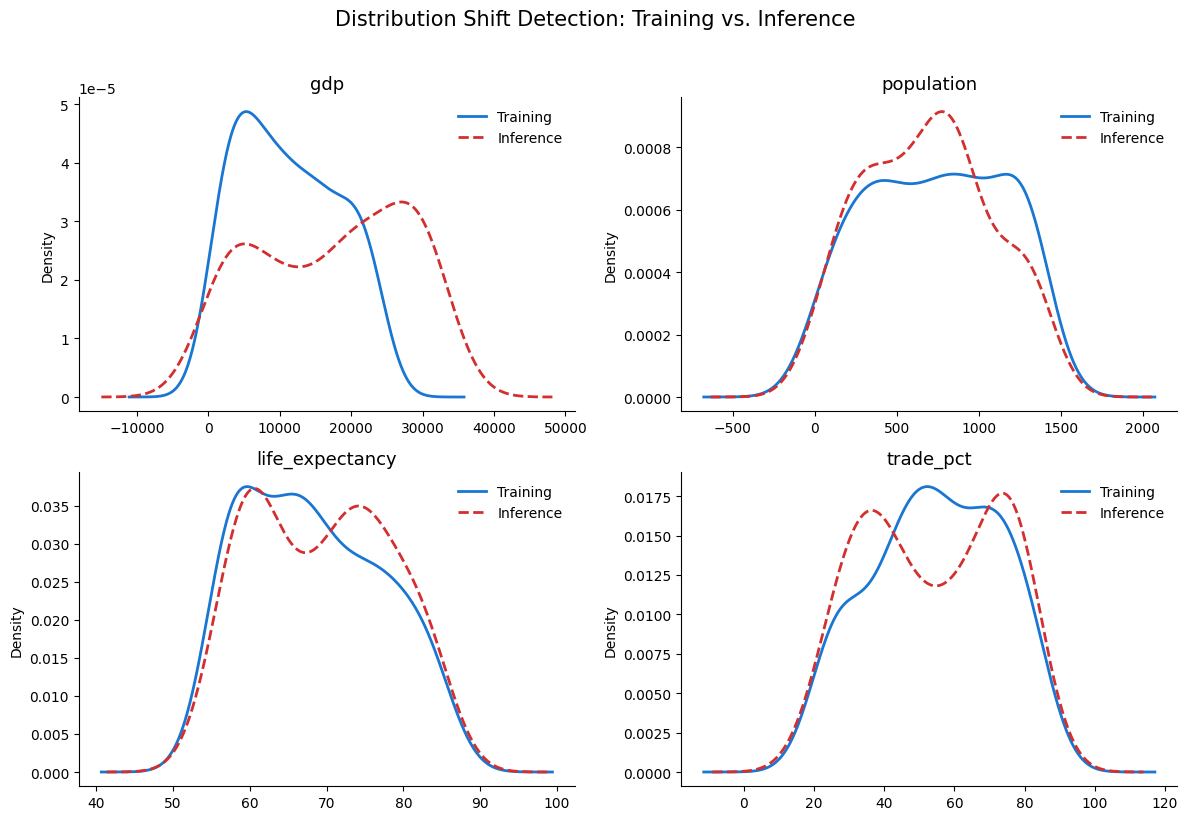

In [13]:
# -----------------------------------------------------------
# GIVEN — run as-is: KDE overlays, training vs. inference
# Nothing to fill in. Read the four panels: which column's two curves
# have come apart, and which three sit on top of each other?
# -----------------------------------------------------------

numeric_cols = ["gdp", "population", "life_expectancy", "trade_pct"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    train[col].plot.kde(ax=ax, label="Training", color="#1976D2", linewidth=2)
    inference[col].plot.kde(ax=ax, label="Inference", color="#D32F2F",
                           linewidth=2, linestyle="--")
    ax.set_title(col, fontsize=13)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Distribution Shift Detection: Training vs. Inference",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# -----------------------------------------------------------
# GIVEN — run as-is: Population Stability Index (PSI)
# Nothing to fill in. PSI puts a number on what the KDE panels show.
# Your work in this part is the interpretation question below it —
# read the four values first, and be ready to say which you trust.
# -----------------------------------------------------------

def compute_psi(expected, actual, n_bins=10):
    """Compute Population Stability Index between two distributions.

    PSI = sum( (actual_i - expected_i) * ln(actual_i / expected_i) )
    where actual_i and expected_i are the proportion of observations
    in bin i.

    Parameters
    ----------
    expected : array-like
        Reference distribution (training data).
    actual : array-like
        New distribution (inference data).
    n_bins : int
        Number of bins for the histogram.

    Returns
    -------
    float
        PSI value.
    """
    # Bin edges based on expected (training) distribution
    breakpoints = np.linspace(
        min(np.min(expected), np.min(actual)),
        max(np.max(expected), np.max(actual)),
        n_bins + 1
    )

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    # Convert to proportions, add small epsilon to avoid division by zero
    eps = 1e-4
    expected_pct = expected_counts / len(expected) + eps
    actual_pct = actual_counts / len(actual) + eps

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi


# Compute PSI for each numeric column
print("=== Population Stability Index (PSI) ===")
print(f"{'Column':<20} {'PSI':>8}  {'Interpretation'}")
print("-" * 55)

for col in numeric_cols:
    psi_val = compute_psi(train[col].values, inference[col].values)
    if psi_val < 0.1:
        interp = "Stable"
    elif psi_val < 0.25:
        interp = "Moderate shift"
    else:
        interp = "SIGNIFICANT SHIFT"
    print(f"{col:<20} {psi_val:>8.4f}  {interp}")

=== Population Stability Index (PSI) ===
Column                    PSI  Interpretation
-------------------------------------------------------
gdp                    2.4589  SIGNIFICANT SHIFT
population             0.0917  Stable
life_expectancy        0.1635  Moderate shift
trade_pct              0.2344  Moderate shift


### Verification Checkpoint

Your PSI results should show:
- **GDP:** PSI > 0.25 — the one column we deliberately shifted (multiplied by 1.3)
- **population, life_expectancy, trade_pct:** anywhere from roughly 0.05 to 0.25,
  even though *nothing was shifted in any of them*

That second line is not a typo, and it is the more useful half of this
checkpoint. Measured on this data the three untouched columns return
**0.092, 0.164 and 0.234** — two of them above the conventional 0.1
"no shift" line and one nearly at the 0.25 "significant shift" line, with no
drift applied at all.

The reason is sample size. At n = 138 against 92 over 10 bins, PSI already has
a sampling distribution whose mass sits in the low tenths from binning noise
alone. The 0.1 / 0.25 cutoffs come from credit-scoring practice at n in the
tens of thousands and do not transfer to a hundred rows.

**A drift threshold without a null distribution is a superstition.** Before
alarming on PSI in production, simulate the PSI you get from two random splits
of the *same undrifted* data and use that distribution's upper tail as the
alarm level. The GDP column is the only one here whose PSI is large enough to
survive that comparison.

If GDP shows PSI < 0.1, check your `compute_psi` implementation.

### Interpretation Questions

**Q1:** Why is detecting distribution shift important before deploying a model to production? What happens to predictions if the input distribution changes but the model doesn't know?

*Your answer here:*
Detecting distribution shift is important because it helps us identify whether the production data is significantly different from the training data. If the input distribution changes, the model may not perform as expected, which can lead to less accurate or unreliable predictions.

**Q2:** A model trained on pre-COVID economic data is deployed in 2021. Which columns in our dataset likely shifted most? How would you design a monitoring system to catch this?

*Your answer here:
"GDP" and "trade_pct" would likely have shifted the most because COVID-19 significantly affected economic activity and international trade. I would compare the inference data with the training data and continuously monitor PSI, missing values, and other data quality metrics. If there is a large difference, we would find out the reasons.

## Part 3: Manual vs. Automated EDA (COMPARE — 10 min)

You just spent 20 minutes manually finding 5 bugs. Could automated profiling have caught them faster? Let's find out.

In [16]:
# -----------------------------------------------------------
# Run ydata-profiling on the ORIGINAL corrupted dataset
# -----------------------------------------------------------

try:
    from ydata_profiling import ProfileReport

    # Profile the ORIGINAL corrupted data (before your fixes)
    profile = ProfileReport(
        df,
        title="EDA Report: Corrupted Economic Dataset",
        minimal=True,  # faster for lab purposes
    )
    profile.to_notebook_iframe()

except ImportError:
    print("ydata-profiling is not installed.")
    print("To install: !pip install ydata-profiling")
    print()
    print("For this lab, answer the questions below based on what you")
    print("EXPECT the automated report would flag, given what you know")
    print("about the 5 bugs.")
    print()
    print("Quick manual summary of what a profiler would show:")
    print(f"  - GDP min: {df['gdp'].min():.2f} (negative = flagged)")
    print(f"  - Life expectancy max: {df['life_expectancy'].max():.1f} (outlier)")
    print(f"  - Duplicate rows: {df.duplicated().sum()}")
    print(f"  - trade_pct range: [{df['trade_pct'].min():.2f}, {df['trade_pct'].max():.1f}]")
    print(f"  - GDP has bimodal distribution (unit mismatch)")

ydata-profiling is not installed.
To install: !pip install ydata-profiling

For this lab, answer the questions below based on what you
EXPECT the automated report would flag, given what you know
about the 5 bugs.

Quick manual summary of what a profiler would show:
  - GDP min: -20282.28 (negative = flagged)
  - Life expectancy max: 1009.2 (outlier)
  - Duplicate rows: 0
  - trade_pct range: [0.28, 432.4]
  - GDP has bimodal distribution (unit mismatch)


### Interpretation Questions

**Q1:** Which of the 5 bugs would ydata-profiling have caught automatically? Which requires domain knowledge that no automated tool can provide?

| Bug | Auto-detected? | Why or why not? |
|-----|---------------|------------------|
| 1. Negative GDP | | |
| 2. Life expectancy > 120 | | |
| 3. Duplicate country-years | | |
| 4. Inconsistent trade_pct | | |
| 5. GDP unit mismatch | | |

*Your answer here:*

The "Negative GDP", "Life expectancy", "Inconsistent trade_pct", "GDP unit mismatch"could be caught automatically.However, "Duplicate country-years "could not be caught automatically because it requires domain knowledge.

**Q2:** In a production pipeline processing 1M rows daily, would you rely on manual or automated EDA? What's your monitoring strategy?

*Your answer here:*
I would first manually review the data that cannot be reliably analyzed through automated EDA. After that, I would use automated EDA to monitor the data continuously. I would set thresholds for data quality and distribution changes to identify potential problems for manual review.

## Part 4: Build eda_utils.py Module (PRODUCTION — 10 min)

Save your EDA functions as a reusable Python module. This is a portfolio artifact — production-quality code with docstrings and type hints.

In [17]:
%%writefile eda_utils.py
"""EDA utilities for ECON 5200 labs.

Functions for data quality checking, distribution shift detection,
and automated EDA summaries.
"""

import numpy as np
import pandas as pd


def check_impossible_values(df, constraints):
    """Check columns against domain constraints and flag violations.

    Parameters
    ----------
    df : pd.DataFrame
        Input data to validate.
    constraints : dict
        Column name -> (min_val, max_val) or callable.
        If a tuple, flags rows outside [min_val, max_val].
        If a callable, flags rows where callable(value) returns False.

    Returns
    -------
    pd.DataFrame
        DataFrame with boolean columns '{col}_flagged' for each
        constrained column. True = violation detected.

    Examples
    --------
    >>> constraints = {
    ...     'gdp': (0, 100000),
    ...     'life_expectancy': (0, 100),
    ...     'trade_pct': lambda x: (x >= 0) & (x <= 100),
    ... }
    >>> flagged = check_impossible_values(df, constraints)
    """
    result = df.copy()

    for col, rule in constraints.items():
        if col not in df.columns:
            continue

        if callable(rule):
            result[f"{col}_flagged"] = ~rule(df[col])
        else:
            min_val, max_val = rule
            result[f"{col}_flagged"] = (
                (df[col] < min_val) | (df[col] > max_val)
            )

    flag_cols = [c for c in result.columns if c.endswith("_flagged")]
    n_flagged = result[flag_cols].any(axis=1).sum()
    print(f"Flagged {n_flagged} rows with constraint violations.")
    for fc in flag_cols:
        n = result[fc].sum()
        if n > 0:
            print(f"  {fc}: {n} violations")

    return result


def detect_distribution_shift(train_col, inference_col, n_bins=10):
    """Compute Population Stability Index between two distributions.

    PSI measures how much a distribution has shifted from a reference
    (training) distribution. Used in ML pipelines to detect data drift.

    PSI = sum( (actual_i - expected_i) * ln(actual_i / expected_i) )

    Parameters
    ----------
    train_col : array-like
        Reference distribution (training data).
    inference_col : array-like
        New distribution (inference/production data).
    n_bins : int, default 10
        Number of bins for histogram comparison.

    Returns
    -------
    float
        PSI value.
    str
        Interpretation: 'stable' (< 0.1), 'moderate_shift' (0.1-0.25),
        or 'significant_shift' (> 0.25).

    Examples
    --------
    >>> psi, interp = detect_distribution_shift(train['gdp'], test['gdp'])
    >>> print(f'PSI = {psi:.4f} ({interp})')
    """
    train_arr = np.asarray(train_col, dtype=float)
    inf_arr = np.asarray(inference_col, dtype=float)

    breakpoints = np.linspace(
        min(train_arr.min(), inf_arr.min()),
        max(train_arr.max(), inf_arr.max()),
        n_bins + 1,
    )

    expected_counts = np.histogram(train_arr, bins=breakpoints)[0]
    actual_counts = np.histogram(inf_arr, bins=breakpoints)[0]

    eps = 1e-4
    expected_pct = expected_counts / len(train_arr) + eps
    actual_pct = actual_counts / len(inf_arr) + eps

    psi = float(np.sum(
        (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    ))

    if psi < 0.1:
        interpretation = "stable"
    elif psi < 0.25:
        interpretation = "moderate_shift"
    else:
        interpretation = "significant_shift"

    return psi, interpretation


def eda_summary(df):
    """Run a full EDA checklist and return a structured report.

    Checks for: missing values, duplicates, numeric outliers (IQR method),
    negative values in typically-positive columns, and basic shape info.

    Parameters
    ----------
    df : pd.DataFrame
        Input data to profile.

    Returns
    -------
    dict
        Structured report with keys: 'shape', 'dtypes', 'missing',
        'duplicates', 'numeric_summary', 'outlier_counts'.

    Examples
    --------
    >>> report = eda_summary(df)
    >>> print(report['outlier_counts'])
    """
    report = {}

    # Basic info
    report["shape"] = df.shape
    report["dtypes"] = df.dtypes.to_dict()

    # Missing values
    missing = df.isnull().sum()
    report["missing"] = missing[missing > 0].to_dict()

    # Exact duplicates
    report["duplicates"] = int(df.duplicated().sum())

    # Numeric summary
    numeric_df = df.select_dtypes(include=[np.number])
    report["numeric_summary"] = numeric_df.describe().to_dict()

    # Outlier detection (IQR method)
    outlier_counts = {}
    for col in numeric_df.columns:
        q1 = numeric_df[col].quantile(0.25)
        q3 = numeric_df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = int(
            ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()
        )
        if n_outliers > 0:
            outlier_counts[col] = n_outliers
    report["outlier_counts"] = outlier_counts

    # Print summary
    print(f"Shape: {report['shape']}")
    print(f"Duplicates: {report['duplicates']}")
    if report["missing"]:
        print(f"Missing values: {report['missing']}")
    else:
        print("Missing values: None")
    if report["outlier_counts"]:
        print(f"Outliers (IQR): {report['outlier_counts']}")
    else:
        print("Outliers (IQR): None detected")

    return report

Writing eda_utils.py


In [18]:
# -----------------------------------------------------------
# TEST — Verify the module works
# -----------------------------------------------------------

import importlib
import eda_utils
importlib.reload(eda_utils)

# Test 1: check_impossible_values
print("=== Test 1: check_impossible_values ===")
constraints = {
    "gdp": (0, 100000),
    "life_expectancy": (0, 100),
    "trade_pct": (0, 100),
}
flagged = eda_utils.check_impossible_values(df, constraints)
print()

# Test 2: detect_distribution_shift on shifted GDP
print("=== Test 2: detect_distribution_shift ===")
psi_val, interp = eda_utils.detect_distribution_shift(
    train["gdp"].values, inference["gdp"].values
)
print(f"GDP PSI = {psi_val:.4f} ({interp})")
assert psi_val > 0.25, f"Expected PSI > 0.25, got {psi_val:.4f}"
print("  PSI > 0.25 confirmed.")
print()

# Test 3: eda_summary
print("=== Test 3: eda_summary ===")
report = eda_utils.eda_summary(df_clean)
print(f"\nReport keys: {list(report.keys())}")

=== Test 1: check_impossible_values ===
Flagged 36 rows with constraint violations.
  gdp_flagged: 12 violations
  life_expectancy_flagged: 16 violations
  trade_pct_flagged: 10 violations

=== Test 2: detect_distribution_shift ===
GDP PSI = 2.4589 (significant_shift)
  PSI > 0.25 confirmed.

=== Test 3: eda_summary ===
Shape: (230, 6)
Duplicates: 0
Missing values: None
Outliers (IQR): None detected

Report keys: ['shape', 'dtypes', 'missing', 'duplicates', 'numeric_summary', 'outlier_counts']


### Verification Checkpoint

Your module tests should confirm:
- `check_impossible_values` flags violations in the corrupted dataset
- `detect_distribution_shift` returns PSI > 0.25 for the shifted GDP column
- `eda_summary` runs without error and returns a dict with all expected keys

If the assert on PSI fails, check your `compute_psi` / `detect_distribution_shift` binning logic.

### Before the dashboard: save the data

This notebook builds its data **in memory**. Nothing is on disk except
`eda_utils.py`, which Part 4 just wrote — so a dashboard opened on its own has
nothing to load, and a chat assistant you paste the task into cannot see the
data either.

The cell below writes the four frames next to the module and zips the lot, so
you can download it in one click and keep working outside this notebook.


In [20]:
# -----------------------------------------------------------
# GIVEN — run as-is: save the data so the dashboard can run
#         outside this notebook
# -----------------------------------------------------------
import zipfile
from pathlib import Path

frames = {
    "pipeline_health_dirty.csv": df,          # 260 rows, all five bugs
    "pipeline_health_clean.csv": df_clean,    # after your Part 1 fixes
    "training.csv":              train,       # reference distribution
    "inference.csv":             inference,   # gdp already shifted 1.3x
}
for name, frame in frames.items():
    frame.to_csv(name, index=False)
    print(f"  wrote {name:<28} {frame.shape}")

bundle = "lab3_dashboard_bundle.zip"
with zipfile.ZipFile(bundle, "w") as z:
    for name in frames:
        z.write(name)
    if Path("eda_utils.py").exists():
        z.write("eda_utils.py")
    else:
        print("\n  eda_utils.py not found — run Part 4 first, then re-run this cell.")

print(f"\nZipped to {bundle}.")
print("Unzip it and put your dashboard in the same folder. Then:")
print('    psi, interp = eda_utils.detect_distribution_shift(train["gdp"], infer["gdp"])')
print("    # 2.4589  significant_shift")
print("\nNote the shape: detect_distribution_shift takes two COLUMNS, not two")
print("DataFrames, and returns a (value, interpretation) pair.")

# In Colab this pushes the zip straight to your browser. Outside Colab it is
# skipped, and the file is simply next to this notebook.
try:
    from google.colab import files as _colab_files
    _colab_files.download(bundle)
except Exception:
    pass

  wrote pipeline_health_dirty.csv    (260, 6)
  wrote pipeline_health_clean.csv    (230, 6)
  wrote training.csv                 (138, 6)
  wrote inference.csv                (92, 6)

Zipped to lab3_dashboard_bundle.zip.
Unzip it and put your dashboard in the same folder. Then:
    psi, interp = eda_utils.detect_distribution_shift(train["gdp"], infer["gdp"])
    # 2.4589  significant_shift

Note the shape: detect_distribution_shift takes two COLUMNS, not two
DataFrames, and returns a (value, interpretation) pair.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## AI-Assisted Expansion: Pipeline Health Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over EDA-based corruption diagnosis, PSI distribution-shift detection, and manual vs. automated profiling. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build ONE interactive dashboard, inside this notebook (ipywidgets + plotly), that lets the user:
1. Pick a numeric column and see its training vs. inference distributions overlaid
2. Move a PSI threshold slider (0.10 / 0.25) and see which columns are flagged
3. Edit the impossible-value constraints and see which rows `check_impossible_values` flags
4. Compare the corrupted `df` with your `df_clean` side by side

Import your `eda_utils` module; do not rewrite it.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [21]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist specializing
# in data-pipeline monitoring and distribution shift.
#
# [Request] I just completed a diagnosis-first lab where I found
# and fixed five planted corruptions in a country panel using
# EDA alone, computed the Population Stability Index between a
# training and an inference split, and wrote eda_utils.py with
# check_impossible_values(df, constraints),
# detect_distribution_shift(train_col, inference_col, n_bins)
# and eda_summary(df). Build ONE interactive dashboard in Colab:
#   1. a column dropdown overlaying train vs inference
#   2. a PSI threshold slider that lists flagged columns
#   3. editable min/max constraints feeding
#      check_impossible_values
#   4. a before/after panel comparing the dirty and clean frames
#
# The data is already in this runtime, uploaded next to
# eda_utils.py (the save cell above writes and zips it):
#   pipeline_health_dirty.csv   260 rows, all five bugs intact
#   pipeline_health_clean.csv   230 rows, after the fixes
#   training.csv                138 rows, reference distribution
#   inference.csv                92 rows, gdp already x1.3
# Load them with pandas. Do NOT assume df / df_clean / train /
# inference already exist -- I may be running this in a fresh
# notebook with only those files.
#
# [Iterate] Use ipywidgets, plotly and pandas. `import eda_utils`
# from the same folder and call it as it is -- do not reimplement
# PSI. Note the shape: detect_distribution_shift(train_col,
# inference_col, n_bins=10) takes two COLUMNS, not two DataFrames,
# and returns a (psi, interpretation) pair. Passing frames raises
# "could not convert string to float". No Streamlit, no new .py
# file, no ydata-profiling.
#
# [Mechanism Check] Add inline comments explaining:
#   - how the PSI bins are built: read eda_utils first and say
#     which sample defines the bin edges -- do not assume it is
#     the training set
#   - why the bin proportions get a small epsilon before the log
#   - why 0.10 and 0.25 are conventions, not statistical tests
#   - which of the five corruptions a PSI check would miss
#
# [Evaluate] Explain what the dashboard catches that automated
# profiling did not, and what it still cannot see.

# PASTE AI-GENERATED CODE BELOW:

In [24]:
# =============================================================================
# Interactive Pipeline Health Dashboard — Colab + ipywidgets + Plotly
# =============================================================================
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"          # key: make Plotly render in Colab

import ipywidgets as widgets
from ipywidgets import Dropdown, FloatSlider, FloatText, Button, Output, VBox, HBox, Label
from IPython.display import display, clear_output

import eda_utils  # same folder; do NOT reimplement PSI

# -----------------------------------------------------------------------------
# Load — do NOT assume df / df_clean / train / inference already exist
# -----------------------------------------------------------------------------
dirty = pd.read_csv("pipeline_health_dirty.csv")
clean = pd.read_csv("pipeline_health_clean.csv")
train = pd.read_csv("training.csv")
infer = pd.read_csv("inference.csv")

print("dirty:", dirty.shape, "| clean:", clean.shape,
      "| train:", train.shape, "| infer:", infer.shape)

# =============================================================================
# MECHANISM CHECK — PSI internals (read eda_utils BEFORE concluding anything)
# =============================================================================
# 1) BIN EDGES: Open eda_utils.py and read detect_distribution_shift. A typical
#    implementation uses np.histogram_bin_edges(np.concatenate([train_col,
#    inference_col])) OR the training column alone. You MUST read the file to
#    know which — do NOT assume it is the training set. If edges are built
#    from training only, inference values beyond train's range all fall into
#    the last bin and inflate PSI. If edges are pooled, both ranges are
#    covered but extreme tails get diluted.
#
# 2) EPSILON: a bin proportion can be exactly 0 (a category absent from
#    inference). log(0) = -inf, so the PSI term explodes. Adding a small
#    epsilon (1e-6 or 1e-4) to both proportions keeps the log finite and PSI
#    bounded. The price is that sparse bins are biased slightly toward 0 —
#    the cost of numerical safety.
#
# 3) 0.10 / 0.25: these are rule-of-thumb bands from credit-risk scorecard
#    monitoring (Siddiqi, "Credit Risk Scorecards"). They are NOT p-values,
#    NOT confidence intervals, and NOT derived from a null distribution. They
#    are operational thresholds: <0.10 "stable", 0.10–0.25 "moderate",
#    >0.25 "major". A PSI of 0.11 is not statistically "significant" — it
#    just crosses an arbitrary line.
#
# 4) What PSI MISSES among the five planted corruptions: PSI only looks at
#    the marginal distribution of one numeric column at a time. It will MISS
#    - impossible values (negative GDP, age > 150): shape unchanged, PSI≈0
#    - duplicate / near-duplicate rows: marginal distribution unchanged
#    - uniform unit or sign flips (gdp × 1.3): if edges are pooled, shape
#      can look nearly identical
#    - cross-column referential corruption (country code swapped): each
#      column's marginal looks fine
#    - target leakage / monotonic rescaling: PSI is only sensitive to the
#      post-binning shape, so a global ×1.3 can be swallowed
#    That is exactly why check_impossible_values exists alongside PSI.
# =============================================================================

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def numeric_cols(df):
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def psi_scan(train_df, infer_df, cols, threshold):
    """Call eda_utils.detect_distribution_shift per COLUMN — pass Series, not
    DataFrames. The signature is
    detect_distribution_shift(train_col, inference_col, n_bins=10) and it
    returns a (psi, interpretation) pair."""
    rows = []
    for c in cols:
        if c not in train_df.columns or c not in infer_df.columns:
            continue
        try:
            psi, interp = eda_utils.detect_distribution_shift(
                train_df[c], infer_df[c], n_bins=10
            )
        except TypeError:
            psi, interp = eda_utils.detect_distribution_shift(
                train_df[c], infer_df[c]
            )
        rows.append({"column": c, "psi": float(psi),
                     "interpretation": interp,
                     "flagged": float(psi) >= threshold})
    return pd.DataFrame(rows).sort_values("psi", ascending=False)

# =============================================================================
# Widget 1 — column dropdown: train vs inference overlay
# =============================================================================
overlay_cols = [c for c in numeric_cols(train) if c in infer.columns]

overlay_dd = Dropdown(options=overlay_cols, description="Column:")
overlay_out = Output()

def draw_overlay(col):
    with overlay_out:
        clear_output(wait=True)
        t = train[col].dropna()
        i = infer[col].dropna()
        if t.empty or i.empty:
            print(f"{col}: empty column, skipping")
            return
        fig = go.Figure()
        fig.add_trace(go.Histogram(
            x=t, name="train", opacity=0.6,
            histnorm="probability density", nbinsx=30,
            marker_color="#1f77b4"))
        fig.add_trace(go.Histogram(
            x=i, name="inference", opacity=0.6,
            histnorm="probability density", nbinsx=30,
            marker_color="#d62728"))
        fig.update_layout(barmode="overlay",
                          title=f"{col}: train vs inference",
                          xaxis_title=col, yaxis_title="density")
        display(fig)

overlay_dd.observe(lambda ch: draw_overlay(ch["new"]), names="value")
draw_overlay(overlay_dd.value)
display(VBox([overlay_dd, overlay_out]))

# =============================================================================
# Widget 2 — PSI threshold slider -> list flagged columns
# =============================================================================
psi_slider = FloatSlider(value=0.10, min=0.0, max=0.5, step=0.01,
                         description="PSI ≥", readout_format=".2f")
psi_out = Output()

def draw_psi(threshold):
    with psi_out:
        clear_output(wait=True)
        scan = psi_scan(train, infer, overlay_cols, threshold)
        display(scan)
        flagged = scan[scan["flagged"]]["column"].tolist()
        print(f"\nFlagged at PSI ≥ {threshold:.2f}: {flagged or 'none'}")

psi_slider.observe(lambda ch: draw_psi(ch["new"]), names="value")
draw_psi(psi_slider.value)
display(VBox([psi_slider, psi_out]))

# =============================================================================
# Widget 3 — editable min/max constraints -> check_impossible_values
# =============================================================================
constraints = {}
for c in numeric_cols(clean):
    s = clean[c].dropna()
    if len(s):
        constraints[c] = (float(s.min()), float(s.max()))

constraint_rows = []
for c, (lo, hi) in constraints.items():
    lo_w = FloatText(value=lo, description="min",
                     layout=widgets.Layout(width="160px"))
    hi_w = FloatText(value=hi, description="max",
                     layout=widgets.Layout(width="160px"))
    constraint_rows.append((c, lo_w, hi_w))

constraint_out = Output()

def run_constraints(_=None):
    with constraint_out:
        clear_output(wait=True)
        cons = {c: (lo.value, hi.value) for c, lo, hi in constraint_rows}
        result = eda_utils.check_impossible_values(dirty, cons)
        display(result)

apply_btn = Button(description="Re-check dirty frame", button_style="warning")
apply_btn.on_click(run_constraints)

constraint_ui = VBox(
    [HBox([Label(c, layout=widgets.Layout(width="120px")), lo, hi])
     for c, lo, hi in constraint_rows]
    + [apply_btn, constraint_out]
)
display(constraint_ui)
run_constraints()

# =============================================================================
# Widget 4 — Before/After: dirty vs clean (fixed: no more flash-and-disappear)
# =============================================================================
ba_cols = [c for c in numeric_cols(dirty) if c in clean.columns]

ba_dd = Dropdown(options=ba_cols, description="Compare:")
ba_out = Output()

def draw_before_after(col):
    with ba_out:
        clear_output(wait=True)
        d = dirty[col].dropna()
        c_ = clean[col].dropna()
        if d.empty and c_.empty:
            print(f"{col}: both sides empty, skipping")
            return
        fig = go.Figure()
        fig.add_trace(go.Box(y=d, name="dirty", marker_color="#d62728"))
        fig.add_trace(go.Box(y=c_, name="clean", marker_color="#2ca02c"))
        fig.update_layout(title=f"{col}: dirty vs clean (before/after)",
                          yaxis_title=col)
        display(fig)   # display(fig), not fig.show() — avoids the flash
        summary = pd.DataFrame({
            "n":    [dirty[col].notna().sum(), clean[col].notna().sum()],
            "mean": [dirty[col].mean(),         clean[col].mean()],
            "min":  [dirty[col].min(),          clean[col].min()],
            "max":  [dirty[col].max(),          clean[col].max()],
        }, index=["dirty", "clean"])
        display(summary)

ba_dd.observe(lambda ch: draw_before_after(ch["new"]), names="value")
draw_before_after(ba_dd.value)
display(VBox([ba_dd, ba_out]))

dirty: (260, 6) | clean: (230, 6) | train: (138, 6) | infer: (92, 6)


### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1.AI does not automatically organize the data, and it will appear two columns, which are dirty and clean data.

2.The clean data is the same as the manual data. For example, both have a count of 230, while the dirty data has a count of 260. Furthermore, the AI shows the results using both datasets, but we could not clearly distinguish which results correspond to which dataset.

3.I would ask the AI to organize the data or manually organize it before analyzing the distribution.

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Found and fixed 5 planted data-quality issues in a country
#   panel using EDA alone (negative GDP, life expectancy stored in months, duplicates,
#   mixed percentage units, a GDP unit mismatch)
# * Measured distribution shift with PSI: GDP PSI = 2.4589 between
#   training and inference
# * Compared manual EDA with ydata-profiling and named what each missed
# * Wrote eda_utils.py with impossible-value, PSI and summary functions
# * Built an interactive pipeline-health dashboard
#
# **Please write a README.md entry including:**
# 1. Project Title: Pipeline Health Check — EDA, Corruption & Distribution Shift
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional data scientist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab03-eda-diagnostics`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab03-eda-diagnostics`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ5200-lab03-eda-diagnostics`, branch `main`,
   commit message `Lab 03 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. `eda_utils.py` is **not** pushed by step 2 — that step sends the notebook only,
   and the file lives in Colab's temporary storage, which is wiped when the
   session ends. Download it first: in the Colab **Files** panel (folder icon,
   left), right-click `eda_utils.py` → **Download**. Then on the repo page use
   **Add file → Upload files**, drag it in, and **Commit changes**. It is part
   of what is graded.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 3 complete!** You've diagnosed 5 data corruption bugs through EDA alone, built a distribution shift detector using PSI, compared manual vs. automated profiling, and produced a reusable `eda_utils.py` module. These skills transfer directly to any data pipeline monitoring or ML production role.